In [1]:
import os
dir_ = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
os.chdir(dir_)

In [2]:
import sys
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_circles, load_iris
from sklearn import preprocessing

# Local modules
import utils
import prior
import transformer
import main
device = 'cuda'
# Settings
matplotlib.use("TkAgg")
warnings.filterwarnings("ignore")
%matplotlib inline

# Fetch and process Old faithful dataset

In [3]:
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/faithful.csv"
faithful_np = pd.read_csv(url, index_col=0).to_numpy()

In [4]:
faithful_standard = preprocessing.MinMaxScaler().fit_transform(faithful_np)
faithful_tensor = torch.tensor(faithful_standard, dtype=torch.float32, device=device)
faithful_tensor = faithful_tensor.unsqueeze(1)

# Model

In [5]:
d_model, nhead, nhid, nlayers = 256, 4, 512, 4
in_features = 2 
num_outputs = 10
model = transformer.Transformer(d_model, nhead, nhid, nlayers,in_features=in_features, buckets_size=num_outputs).to(device)
print(f"total params:{sum(p.numel() for p in model.parameters())}")

checkpoint = torch.load("models/models_original/pfn_easy_2D.pt", weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() 
print("")

total params:2115850



# Fit Model

In [12]:
# first forward pass to get cluster prediction
_,cluster_output = model(faithful_tensor, torch.full((1,1), 0, dtype=torch.long, device=device))
predictions_cluster_count = (torch.argmax(cluster_output, dim=-1) + 1).squeeze(0).item() 
cluster_output = cluster_output.cpu()

# second forward pass to get responsibilities
logits,_ = model(faithful_tensor, torch.full((1,1), predictions_cluster_count, dtype=torch.long, device=device))
logits = logits.squeeze(1)
predictions = torch.argmax(logits, dim=1)
predictions = predictions.cpu()

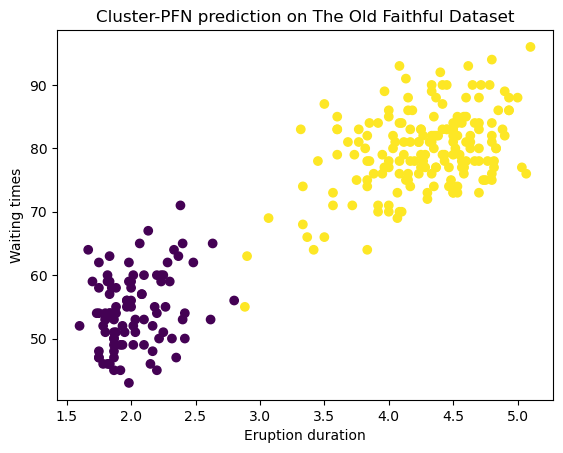

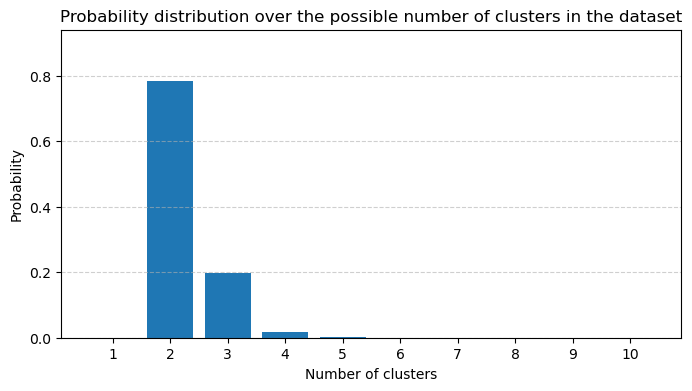

In [13]:
plt.scatter(faithful_np[:, 0] , faithful_np[:, 1], c=predictions)
plt.title("Cluster-PFN prediction on The Old Faithful Dataset")
plt.xlabel("Eruption duration")
plt.ylabel("Waiting times")
plt.show()


probs_tensor = F.softmax(cluster_output, dim=-1)  # still shape [1, 1, 10]
probs = probs_tensor.squeeze().detach().numpy()
bins = np.arange(1, 11)

#Plot
plt.figure(figsize=(8, 4))
plt.bar(bins, probs, tick_label=bins)
plt.xlabel("Number of clusters")
plt.ylabel("Probability")
plt.title("Probability distribution over the possible number of clusters in the dataset")
plt.ylim(0, max(probs) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Example of 5D model

# load Data

In [15]:
num_features = 5
seed = 42
mean_precision_prior = 0.1
X, y, X_true, batch_clusters = prior.generate_bayesian_gmm_data(batch_size=1,
                                                                seq_len=500,
                                                                num_features=num_features,
                                                                mean_precision_prior = mean_precision_prior,
                                                                seed=seed)


print(f"Number of clusters generated: {batch_clusters.item()}")

Number of clusters generated: 7


# Model

In [16]:
d_model, nhead, nhid, nlayers = 256, 4, 512, 4
in_features = 5
num_outputs = 10
model = transformer.Transformer(d_model, nhead, nhid, nlayers,in_features=in_features, buckets_size=num_outputs).to(device)
print(f"total params:{sum(p.numel() for p in model.parameters())}")

checkpoint = torch.load("models/models_original/pfn_hard_5D.pt", weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() 
print("")

total params:2117386



# Fit Model

In [ ]:
_,cluster_output = model(X, torch.full((1,1), 0, dtype=torch.long, device=device))
predictions_cluster_count = (torch.argmax(cluster_output, dim=-1) + 1).squeeze(0).item() 
cluster_output = cluster_output.cpu()
print(predictions_cluster_count)
logits,_ = model(faithful_tensor, torch.full((1,1), predictions_cluster_count, dtype=torch.long, device=device))
logits = logits.squeeze(1)
predictions = torch.argmax(logits, dim=1)
predictions = predictions.cpu()

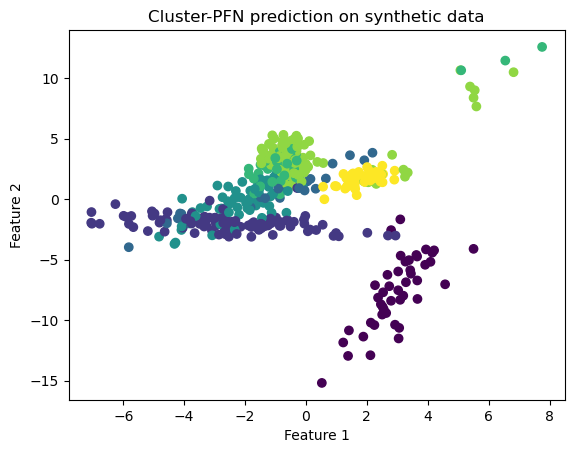

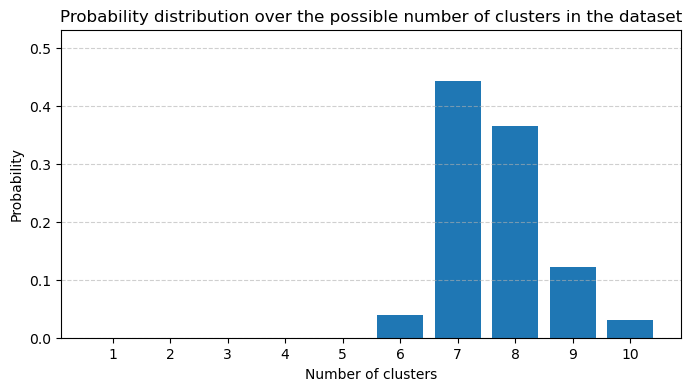

In [11]:
plt.scatter(X_true[:,0, 0].cpu().numpy() , X_true[:,0, 1].cpu().numpy(), c=predictions)
plt.title("Cluster-PFN prediction on synthetic data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


probs_tensor = F.softmax(cluster_output, dim=-1)  # still shape [1, 1, 10]
probs = probs_tensor.squeeze().detach().numpy()
bins = np.arange(1, 11)

#Plot
plt.figure(figsize=(8, 4))
plt.bar(bins, probs, tick_label=bins)
plt.xlabel("Number of clusters")
plt.ylabel("Probability")
plt.title("Probability distribution over the possible number of clusters in the dataset")
plt.ylim(0, max(probs) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()